In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from rasterio.features import geometry_mask
from shapely.geometry import shape
import geopandas as gpd

In [2]:
era5_path = r"P:\snowmelt_stochastic_model\data\raw\era5_chandra_temp_2018_2022.nc"

ds = xr.open_dataset(era5_path)

# Convert to Celsius
temp = ds['t2m'] - 273.15

print(ds)

<xarray.Dataset> Size: 227kB
Dimensions:     (valid_time: 1826, latitude: 5, longitude: 5)
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 15kB 2018-01-01 ... 2022-12-31
  * latitude    (latitude) float64 40B 33.0 32.75 32.5 32.25 32.0
  * longitude   (longitude) float64 40B 76.5 76.75 77.0 77.25 77.5
    expver      (valid_time) <U4 29kB ...
Data variables:
    t2m         (valid_time, latitude, longitude) float32 183kB 249.4 ... 253.0
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-04-15T10:15 GRIB to CDM+CF via cfgrib-0.9.1...


In [3]:
basin_path = r"P:\snowmelt_stochastic_model\data\processed\basin_mask.tif"

with rasterio.open(basin_path) as src:
    basin_mask = src.read(1)
    basin_transform = src.transform
    basin_crs = src.crs

print("Basin loaded")

Basin loaded


In [4]:
from rasterio.features import shapes

mask = basin_mask == 1

shapes_gen = shapes(basin_mask.astype(np.uint8), mask=mask, transform=basin_transform)

geoms = [shape(geom) for geom, value in shapes_gen if value == 1]

basin_gdf = gpd.GeoDataFrame(geometry=geoms, crs=basin_crs)

basin_gdf = basin_gdf.to_crs("EPSG:4326")  # convert to lat/lon

In [5]:
lats = ds.latitude.values
lons = ds.longitude.values

lon2d, lat2d = np.meshgrid(lons, lats)

from shapely.geometry import Point

mask_era5 = np.zeros(lon2d.shape, dtype=bool)

for i in range(lat2d.shape[0]):
    for j in range(lat2d.shape[1]):
        point = Point(lon2d[i, j], lat2d[i, j])
        if basin_gdf.contains(point).any():
            mask_era5[i, j] = True

print("ERA5 mask created")

ERA5 mask created


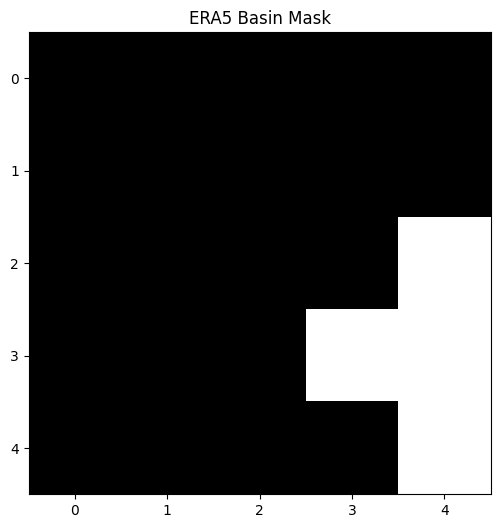

In [6]:
plt.figure(figsize=(6,6))
plt.imshow(mask_era5, cmap='gray')
plt.title("ERA5 Basin Mask")
plt.show()

In [7]:
temp_masked = temp.where(mask_era5)

temp_basin = temp_masked.mean(dim=['latitude', 'longitude'])

print(temp_basin)

<xarray.DataArray 't2m' (valid_time: 1826)> Size: 7kB
array([-24.830536, -26.495514, -23.26825 , ..., -14.895351,  -9.919769,
       -24.231064], shape=(1826,), dtype=float32)
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 15kB 2018-01-01 ... 2022-12-31
    expver      (valid_time) <U4 29kB ...


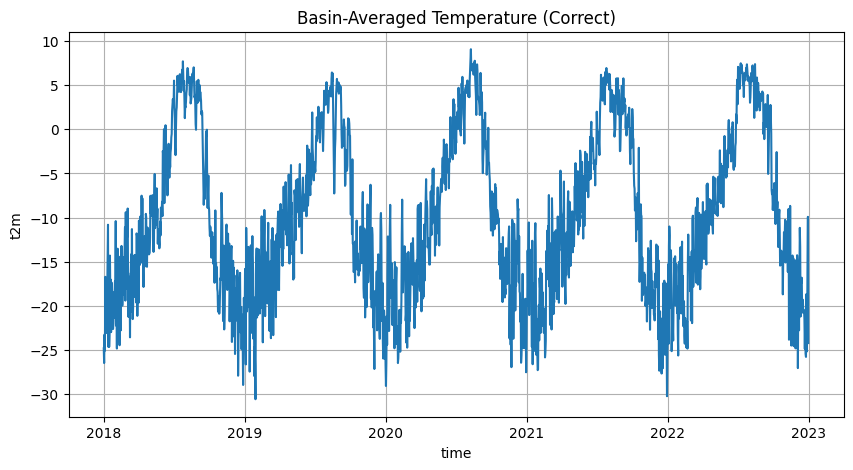

In [8]:
plt.figure(figsize=(10,5))
temp_basin.plot()
plt.title("Basin-Averaged Temperature (Correct)")
plt.grid()
plt.show()

In [9]:
# =========================
# DETERMINISTIC SNOWMELT
# =========================

T = temp_basin  # already basin-averaged

# Degree Day Factor (mm/day/°C)
DDF = 4  

# Threshold temperature
T_base = 0  

# Snowmelt equation
melt_det = DDF * (T - T_base)
melt_det = melt_det.where(melt_det > 0, 0)

print("Deterministic melt computed")

Deterministic melt computed


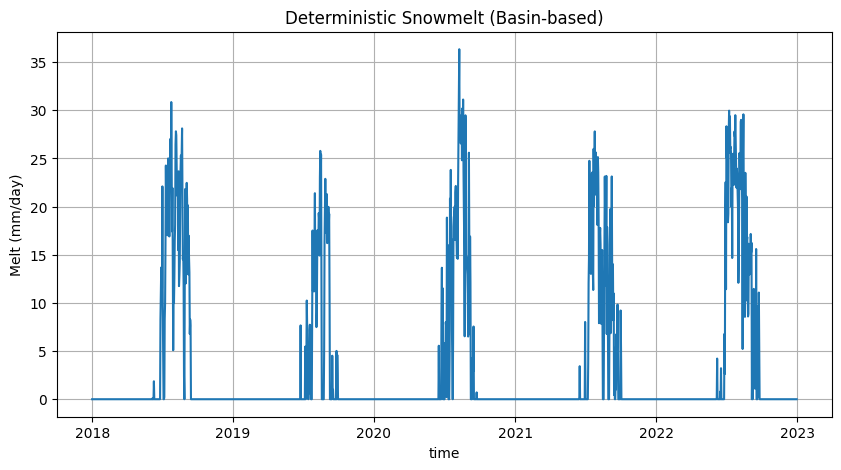

In [10]:
plt.figure(figsize=(10,5))
melt_det.plot()
plt.title("Deterministic Snowmelt (Basin-based)")
plt.ylabel("Melt (mm/day)")
plt.grid()
plt.show()

In [11]:
# =========================
# STOCHASTIC SNOWMELT
# =========================

np.random.seed(42)

# Define variability (temperature dependent)
sigma = 0.3 * melt_det + 1  # ensures non-zero variance

# Random noise
epsilon = np.random.normal(0, 1, size=melt_det.shape)

# Stochastic melt
melt_stoch = melt_det + sigma * epsilon

# No negative melt
melt_stoch = melt_stoch.where(melt_stoch > 0, 0)

print("Stochastic melt computed")

Stochastic melt computed


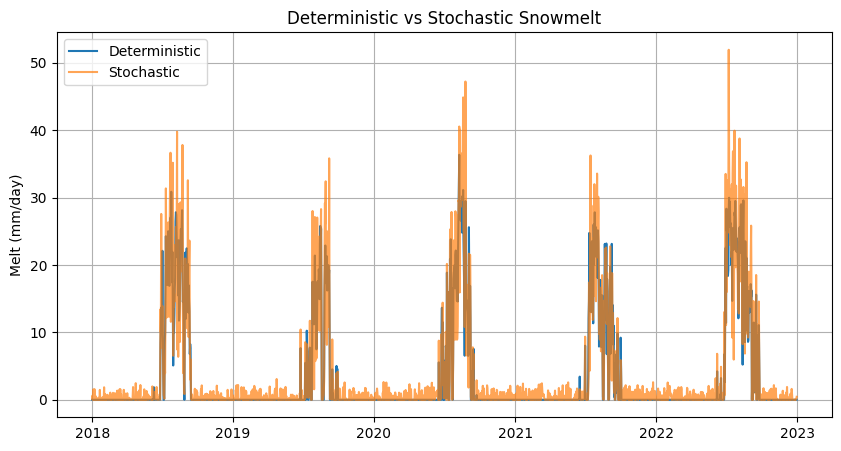

In [13]:
plt.figure(figsize=(10,5))

plt.plot(melt_det['valid_time'], melt_det, label="Deterministic")
plt.plot(melt_stoch['valid_time'], melt_stoch, label="Stochastic", alpha=0.7)

plt.title("Deterministic vs Stochastic Snowmelt")
plt.ylabel("Melt (mm/day)")
plt.legend()
plt.grid()

plt.show()

In [14]:
# =========================
# MONTE CARLO SIMULATION
# =========================

n_sim = 50
melt_ensemble = []

for i in range(n_sim):
    epsilon = np.random.normal(0, 1, size=melt_det.shape)
    melt_sim = melt_det + sigma * epsilon
    melt_sim = melt_sim.where(melt_sim > 0, 0)
    melt_ensemble.append(melt_sim.values)

melt_ensemble = np.array(melt_ensemble)

print("Monte Carlo ensemble created:", melt_ensemble.shape)

Monte Carlo ensemble created: (50, 1826)


In [15]:
# Percentiles
p10 = np.percentile(melt_ensemble, 10, axis=0)
p90 = np.percentile(melt_ensemble, 90, axis=0)
mean_sim = np.mean(melt_ensemble, axis=0)

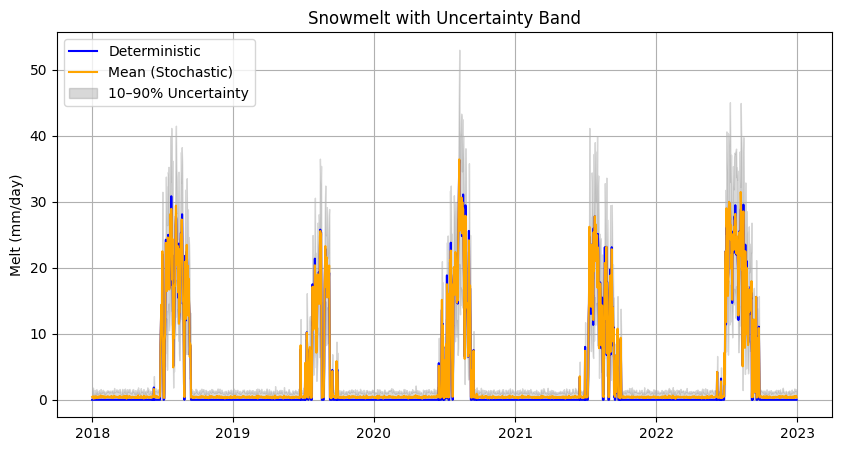

In [17]:
plt.figure(figsize=(10,5))

time = melt_det['valid_time']

plt.plot(time, melt_det, label="Deterministic", color='blue')
plt.plot(time, mean_sim, label="Mean (Stochastic)", color='orange')

plt.fill_between(
    time.values,
    p10,
    p90,
    color='gray',
    alpha=0.3,
    label="10–90% Uncertainty"
)

plt.title("Snowmelt with Uncertainty Band")
plt.ylabel("Melt (mm/day)")
plt.legend()
plt.grid()

plt.show()

In [18]:
# =========================
# BASIN ELEVATION
# =========================

with rasterio.open(r"P:\snowmelt_stochastic_model\data\raw\SRTM\n32_e077_1arc_v3.tif") as src:
    dem_full = src.read(1).astype(float)

# Clean DEM
dem_full[dem_full < 0] = np.nan

# Resize basin mask to DEM if needed (assuming same grid here)
# If not same, we will fix later

# Use same basin mask (from delineation)
# NOTE: if mismatch occurs, tell me

basin_elev = dem_full[basin_mask == 1]

mean_elev = np.nanmean(basin_elev)

print("Mean basin elevation:", mean_elev)

Mean basin elevation: 4867.319922266925


In [19]:
# =========================
# PHYSICALLY INFORMED SIGMA
# =========================

# Normalize elevation (scale effect)
elev_factor = mean_elev / 5000  # ~0.5–1.5 range

# Temperature variability
temp_grad = np.abs(np.gradient(T))

# Sigma formulation
sigma = 0.2 * melt_det + 0.5 * temp_grad + elev_factor

print("Sigma constructed")

Sigma constructed


In [20]:
# =========================
# AR(1) STOCHASTIC PROCESS
# =========================

np.random.seed(42)

phi = 0.7  # persistence (important parameter)

epsilon = np.zeros(len(melt_det))

eta = np.random.normal(0, 1, size=len(melt_det))

for t in range(1, len(epsilon)):
    epsilon[t] = phi * epsilon[t-1] + eta[t]

print("AR(1) noise generated")

AR(1) noise generated


In [21]:
# =========================
# FINAL STOCHASTIC MODEL
# =========================

melt_stoch_ar1 = melt_det + sigma * epsilon

# No negative melt
melt_stoch_ar1 = melt_stoch_ar1.where(melt_stoch_ar1 > 0, 0)

print("Final AR1 stochastic melt computed")

Final AR1 stochastic melt computed


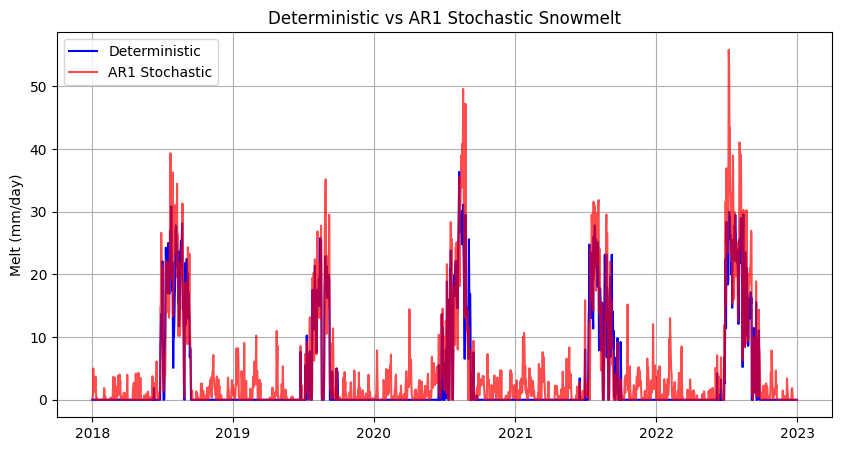

In [22]:
plt.figure(figsize=(10,5))

plt.plot(melt_det['valid_time'], melt_det, label="Deterministic", color='blue')
plt.plot(melt_stoch_ar1['valid_time'], melt_stoch_ar1, label="AR1 Stochastic", color='red', alpha=0.7)

plt.title("Deterministic vs AR1 Stochastic Snowmelt")
plt.ylabel("Melt (mm/day)")
plt.legend()
plt.grid()

plt.show()

In [23]:
# =========================
# JUMP DIFFUSION MODEL
# =========================

np.random.seed(42)

phi = 0.7
jump_prob = 0.02   # ~2% days have jumps
jump_scale = 10    # magnitude of jumps

n = len(melt_det)

epsilon = np.zeros(n)

eta = np.random.normal(0, 1, n)

# Jump process
jumps = np.random.rand(n) < jump_prob
jump_sizes = np.random.normal(0, jump_scale, n)

for t in range(1, n):
    jump_term = jump_sizes[t] if jumps[t] else 0
    epsilon[t] = phi * epsilon[t-1] + eta[t] + jump_term

print("Jump diffusion noise created")

Jump diffusion noise created


In [24]:
melt_jump = melt_det + sigma * epsilon
melt_jump = melt_jump.where(melt_jump > 0, 0)

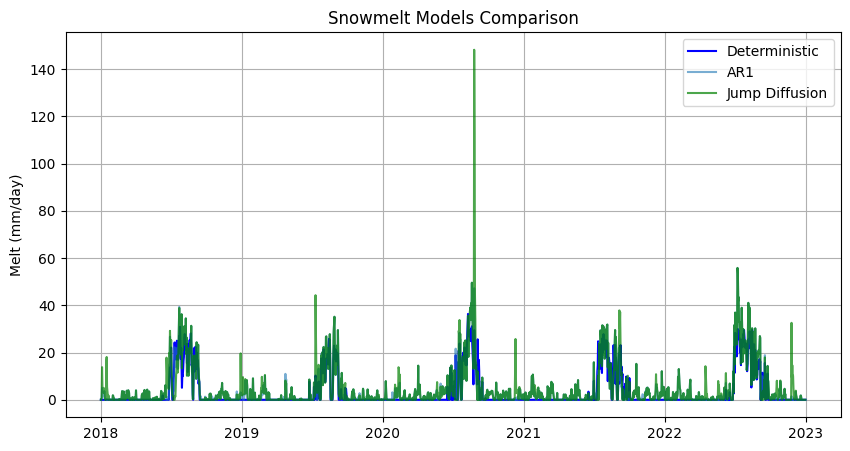

In [25]:
plt.figure(figsize=(10,5))

time = melt_det['valid_time']

plt.plot(time, melt_det, label="Deterministic", color='blue')
plt.plot(time, melt_stoch_ar1, label="AR1", alpha=0.6)
plt.plot(time, melt_jump, label="Jump Diffusion", color='green', alpha=0.7)

plt.title("Snowmelt Models Comparison")
plt.ylabel("Melt (mm/day)")
plt.legend()
plt.grid()

plt.show()

In [27]:
# =========================
# TEMPERATURE-TRIGGERED JUMP MODEL (FULL CELL - FIXED)
# =========================

import numpy as np

np.random.seed(42)

# Extract temperature values
T_vals = T.values
n = len(T_vals)

# AR(1) parameter
phi = 0.7

# Base Gaussian noise
eta = np.random.normal(0, 1, n)

# -------------------------
# TEMPERATURE TRIGGER
# -------------------------
jump_condition = T_vals > 5          # only warm conditions
random_trigger = np.random.rand(n) < 0.2  # not every warm day

jumps = jump_condition & random_trigger

# -------------------------
# SAFE JUMP SCALE (FIXED)
# -------------------------
# Ensure positive standard deviation
jump_scale = 5 + 0.5 * np.maximum(T_vals, 0)

# Generate jump sizes
jump_sizes = np.random.normal(0, jump_scale, n)

# -------------------------
# AR1 + JUMPS
# -------------------------
epsilon_temp_jump = np.zeros(n)

for t in range(1, n):
    jump_term = jump_sizes[t] if jumps[t] else 0
    epsilon_temp_jump[t] = phi * epsilon_temp_jump[t-1] + eta[t] + jump_term

# -------------------------
# FINAL MELT
# -------------------------
melt_temp_jump = melt_det + sigma * epsilon_temp_jump
melt_temp_jump = melt_temp_jump.where(melt_temp_jump > 0, 0)

print("Temperature-triggered jump model ready")

Temperature-triggered jump model ready


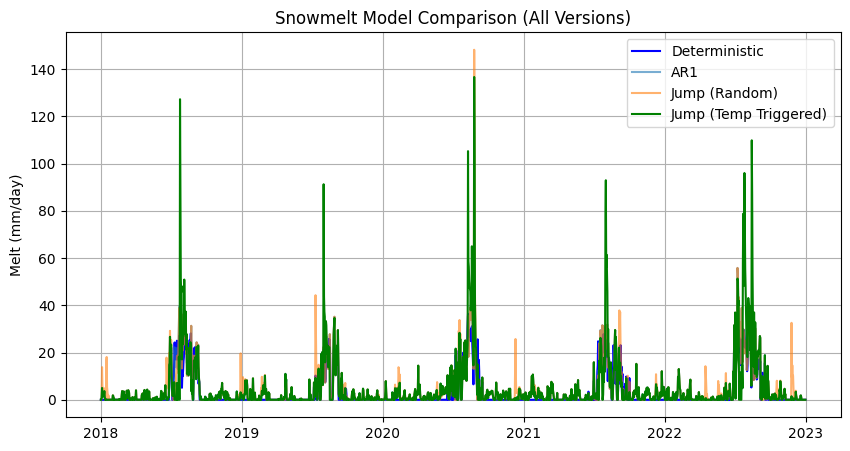

In [28]:
# =========================
# MODEL COMPARISON PLOT
# =========================

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

time = melt_det['valid_time']

plt.plot(time, melt_det, label="Deterministic", color='blue')
plt.plot(time, melt_stoch_ar1, label="AR1", alpha=0.6)
plt.plot(time, melt_jump, label="Jump (Random)", alpha=0.6)
plt.plot(time, melt_temp_jump, label="Jump (Temp Triggered)", color='green')

plt.title("Snowmelt Model Comparison (All Versions)")
plt.ylabel("Melt (mm/day)")
plt.legend()
plt.grid()

plt.show()

In [29]:
# =========================
# TEMPERATURE-TRIGGERED JUMP MODEL (CONTROLLED)
# =========================

import numpy as np

np.random.seed(42)

T_vals = T.values
n = len(T_vals)

phi = 0.7

eta = np.random.normal(0, 1, n)

# -------------------------
# TRIGGER
# -------------------------
jump_condition = T_vals > 5
random_trigger = np.random.rand(n) < 0.15

jumps = jump_condition & random_trigger

# -------------------------
# CONTROLLED JUMP SCALE
# -------------------------
# Smaller, physically realistic
jump_scale = 2 + 0.2 * np.maximum(T_vals, 0)

jump_sizes = np.random.normal(0, jump_scale, n)

# -------------------------
# AR1 + JUMPS
# -------------------------
epsilon_temp_jump = np.zeros(n)

for t in range(1, n):
    jump_term = jump_sizes[t] if jumps[t] else 0
    epsilon_temp_jump[t] = phi * epsilon_temp_jump[t-1] + eta[t] + jump_term

# -------------------------
# FINAL MELT
# -------------------------
melt_temp_jump = melt_det + sigma * epsilon_temp_jump

# Clamp unrealistic extremes (important)
melt_temp_jump = melt_temp_jump.clip(min=0, max=80)

print("Controlled jump model ready")

Controlled jump model ready


In [30]:
# =========================
# STATISTICAL COMPARISON
# =========================

import pandas as pd
import numpy as np

def compute_stats(data, name):
    return {
        "Model": name,
        "Mean Melt": float(np.nanmean(data)),
        "Std Dev": float(np.nanstd(data)),
        "Max Melt": float(np.nanmax(data)),
        "90th Percentile": float(np.nanpercentile(data, 90)),
        "95th Percentile": float(np.nanpercentile(data, 95))
    }

stats = []

stats.append(compute_stats(melt_det.values, "Deterministic"))
stats.append(compute_stats(melt_stoch_ar1.values, "AR1"))
stats.append(compute_stats(melt_jump.values, "Jump (Random)"))
stats.append(compute_stats(melt_temp_jump.values, "Jump (Temp Triggered)"))

df_stats = pd.DataFrame(stats)

print(df_stats)

                   Model  Mean Melt   Std Dev    Max Melt  90th Percentile  \
0          Deterministic   3.209994  7.279509   36.344360        16.184692   
1                    AR1   4.421367  8.204098   55.817959        15.959618   
2          Jump (Random)   4.846338  9.405438  148.176810        17.665218   
3  Jump (Temp Triggered)   4.541329  9.041119   80.000000        15.802868   

   95th Percentile  
0        22.221313  
1        24.029244  
2        25.111201  
3        24.899625  


In [31]:
# =========================
# RUNOFF ESTIMATION
# =========================

k = 0.7  # runoff coefficient (typical range 0.5–0.9)

runoff_det = k * melt_det
runoff_ar1 = k * melt_stoch_ar1
runoff_jump = k * melt_jump
runoff_temp_jump = k * melt_temp_jump

print("Runoff computed")

Runoff computed


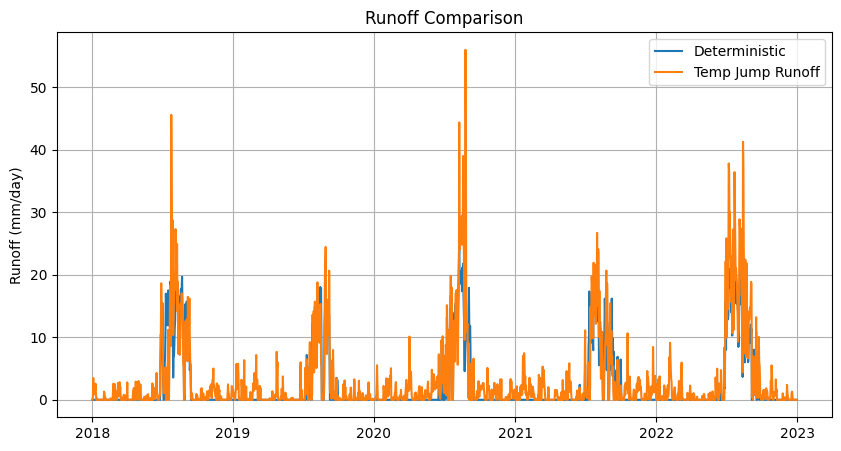

In [32]:
plt.figure(figsize=(10,5))

time = melt_det['valid_time']

plt.plot(time, runoff_det, label="Deterministic")
plt.plot(time, runoff_temp_jump, label="Temp Jump Runoff")

plt.title("Runoff Comparison")
plt.ylabel("Runoff (mm/day)")
plt.legend()
plt.grid()

plt.show()

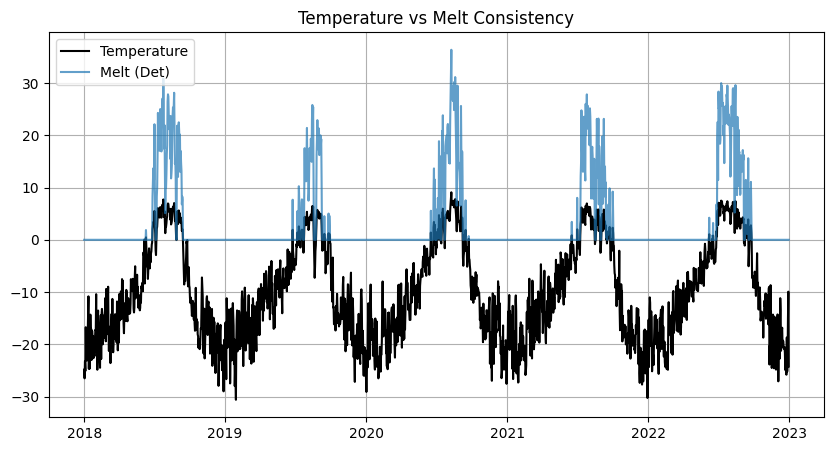

In [33]:
# =========================
# CONSISTENCY CHECK (PROXY VALIDATION)
# =========================

plt.figure(figsize=(10,5))

plt.plot(T['valid_time'], T, label="Temperature", color='black')
plt.plot(melt_det['valid_time'], melt_det, label="Melt (Det)", alpha=0.7)

plt.title("Temperature vs Melt Consistency")
plt.legend()
plt.grid()

plt.show()

In [34]:
# =========================
# MONTE CARLO (CLEAN VERSION)
# =========================

n_sim = 50

ensemble_temp_jump = []

for i in range(n_sim):
    
    eta = np.random.normal(0, 1, n)
    epsilon = np.zeros(n)
    
    for t in range(1, n):
        jump_term = jump_sizes[t] if jumps[t] else 0
        epsilon[t] = phi * epsilon[t-1] + eta[t] + jump_term
    
    melt_sim = melt_det + sigma * epsilon
    melt_sim = melt_sim.clip(min=0, max=80)
    
    ensemble_temp_jump.append(melt_sim.values)

ensemble_temp_jump = np.array(ensemble_temp_jump)

print("Monte Carlo complete:", ensemble_temp_jump.shape)

Monte Carlo complete: (50, 1826)


In [35]:
p10 = np.percentile(ensemble_temp_jump, 10, axis=0)
p90 = np.percentile(ensemble_temp_jump, 90, axis=0)
mean_mc = np.mean(ensemble_temp_jump, axis=0)